In [7]:
# import the necessary packages
import cv2
import numpy as np
from matplotlib import font_manager, rc, rcParams
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage import io, color, measure
from skimage.restoration import denoise_nl_means
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
import pandas as pd
import argparse
import imutils
import warnings
import gc
import os

warnings.simplefilter(action='ignore', category=FutureWarning)
%matplotlib inline

# Install Times New Roman font and rebuild font cache
!apt-get update # Update package lists first
!apt-get install -y ttf-mscorefonts-installer # Correct package for Times New Roman

# Delete the matplotlib font cache to force a rebuild
cache_dir = os.path.join(os.path.expanduser('~'), '.cache', 'matplotlib')
if os.path.exists(cache_dir):
    for filename in os.listdir(cache_dir):
        if filename.startswith('fontlist-'):
            os.remove(os.path.join(cache_dir, filename))

rcParams['figure.dpi'] = 600
rc('font',family='Times New Roman',size=10)
rcParams['axes.titlepad'] = 10
rcParams['mathtext.fontset'] = 'dejavuserif'
ticks_font = font_manager.FontProperties(family='Times New Roman', style='normal',
size=15, weight='normal', stretch='normal')
axis_font = {'fontname':'Times New Roman','fontsize':10}

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://cli.github.com/packages stable/main amd64 Packages [355 B]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [99.9 kB]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [3,106 kB]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy/main amd64 Packages [38.6 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages 

In [8]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [9]:
image = '/content/gdrive/MyDrive/Kigen/ML_STL/0.png'

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from google.colab.patches import cv2_imshow
from google.colab import drive

# Mount Google Drive first
drive.mount('/content/gdrive')

# Re-assign the image path to ensure it's a string
image = '/content/gdrive/MyDrive/Kigen/ML_STL/0.png'

x, y = 0, 0
w, h = 4096, 4096

# Check if the file exists and is readable
import os
if not os.path.exists(image):
    print(f"Error: File '{image}' does not exist!")
    print("Please check the path and make sure the file exists.")
else:
    print(f"File found: {image}")

original_image = cv2.imread(image)

if original_image is None:
    print(f"Error: Could not load image from '{image}'")
    print("Possible reasons:")
    print("1. The file might be corrupted")
    print("2. The file might not be an image format that OpenCV can read")
    print("3. The file path might be incorrect")

    # Try to list files in the directory to help debug
    dir_path = '/content/gdrive/MyDrive/Kigen/ML_STL/'
    if os.path.exists(dir_path):
        print(f"\nFiles in {dir_path}:")
        print(os.listdir(dir_path))
    else:
        print(f"\nDirectory '{dir_path}' does not exist!")
else:
    # Only proceed if image loaded successfully
    crop_image = original_image[x:x+w, y:y+h]
    cv2_imshow(crop_image)

    pixels_to_nm = (103.70/4096)  # 1 pixel = 2.955nm

    shifted = cv2.pyrMeanShiftFiltering(crop_image, 21, 51)
    gray = cv2.cvtColor(shifted, cv2.COLOR_BGR2GRAY)
    ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)

    kernel = np.ones((3,3), np.uint8)
    eroded = cv2.erode(thresh, kernel, iterations=1)
    dilated = cv2.dilate(eroded, kernel, iterations=1)

    # compute the exact Euclidean distance from every binary
    # pixel to the nearest zero pixel, then find peaks in this
    # distance map
    D = ndimage.distance_transform_edt(dilated)
    localMax = peak_local_max(D, min_distance=15, labels=dilated)

    # Create a boolean array for markers with the same shape as D
    markers_image = np.zeros(D.shape, dtype=bool)
    markers_image[tuple(localMax.T)] = True

    # perform a connected component analysis on the local peaks,
    # using 8-connectivity, then apply the Watershed algorithm
    markers = ndimage.label(markers_image, structure=np.ones((3, 3)))[0]
    labels = watershed(-D, markers, mask=dilated)

    plt.figure('Original')
    plt.subplot(2,2,1)
    plt.gca().set_title('Original')
    plt.xticks([]), plt.yticks([])  # To hide axes
    plt.imshow(original_image, cmap='gray')

    plt.subplot(2,2,2)
    plt.gca().set_title('Cropped')
    plt.xticks([]), plt.yticks([])
    plt.imshow(crop_image, cmap='gray')

    plt.subplot(2,2,3)
    plt.gca().set_title('Threshold')
    plt.xticks([]), plt.yticks([])  # To hide axes
    plt.imshow(thresh, cmap='gray')

    plt.subplot(2,2,4)
    plt.gca().set_title('Labeled')
    plt.xticks([]), plt.yticks([])
    plt.imshow(labels)
    plt.show()

    print("[INFO] {} Nanoparticles found in the micrograph".format(len(np.unique(labels)) - 1))

Output hidden; open in https://colab.research.google.com to view.

In [11]:
# loop over the unique labels returned by the Watershed algorithm
for label in np.unique(labels):
    # if the label is zero, we are examining the 'background'
    # so simply ignore it
    if label == 0:
        continue
    # otherwise, allocate memory for the label region and draw
    # it on the mask
    mask = np.zeros(gray.shape, dtype="uint8")
    mask[labels == label] = 255
    # detect contours in the mask and grab the largest one
    cnts = cv2.findContours(mask.copy(), cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE)
    cnts = imutils.grab_contours(cnts)

    c = max(cnts, key=cv2.contourArea)
    # draw a circle enclosing the object
    ((x, y), r) = cv2.minEnclosingCircle(c)
    cv2.circle(original_image, (int(x), int(y)), int(r), (255, 0, 0), 2)
    cv2.putText(original_image, "#{}".format(label), (int(x) - 10, int(y)),
        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

# show the output image
cv2.imwrite('0_Segmented_Image.png', original_image)

plt.figure(figsize=(12, 8))
plt.xticks([]), plt.yticks([])
plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
plt.title(f"Segmented Nanoparticles (Found: {len(np.unique(labels)) - 1})")
plt.show()

# Also display in Colab
cv2_imshow(original_image)

Output hidden; open in https://colab.research.google.com to view.

In [14]:
clusters = measure.regionprops(labels, crop_image)

#We will onle calulate area and eccentricity
propList = ['Area',
           'eccentricity']

output_file = open('0_Measurements.csv', 'w')
output_file.write(',' + ",".join(propList) + '\n')

for cluster_props in clusters:
    #Output desired properties into excel
    output_file.write(str(cluster_props['Label']))

    for i,prop in enumerate(propList):
        if (prop.find('Area') <20):
            to_print = cluster_props[prop]*pixels_to_nm**2
        elif(prop.find('Area') >4):
            to_print = cluster_props[prop]*pixels_to_nm**2
        elif(prop.find('eccentricity') <1):
            to_print = cluster_props[prop]
        else:
            to_print = cluster_props[prop]
        output_file.write(',' + str(to_print))
    output_file.write('\n')

count    97.000000
mean     18.300133
std       9.233221
min       4.841886
25%      11.544508
50%      16.484463
75%      24.420952
max      38.486395
Name: Area, dtype: float64


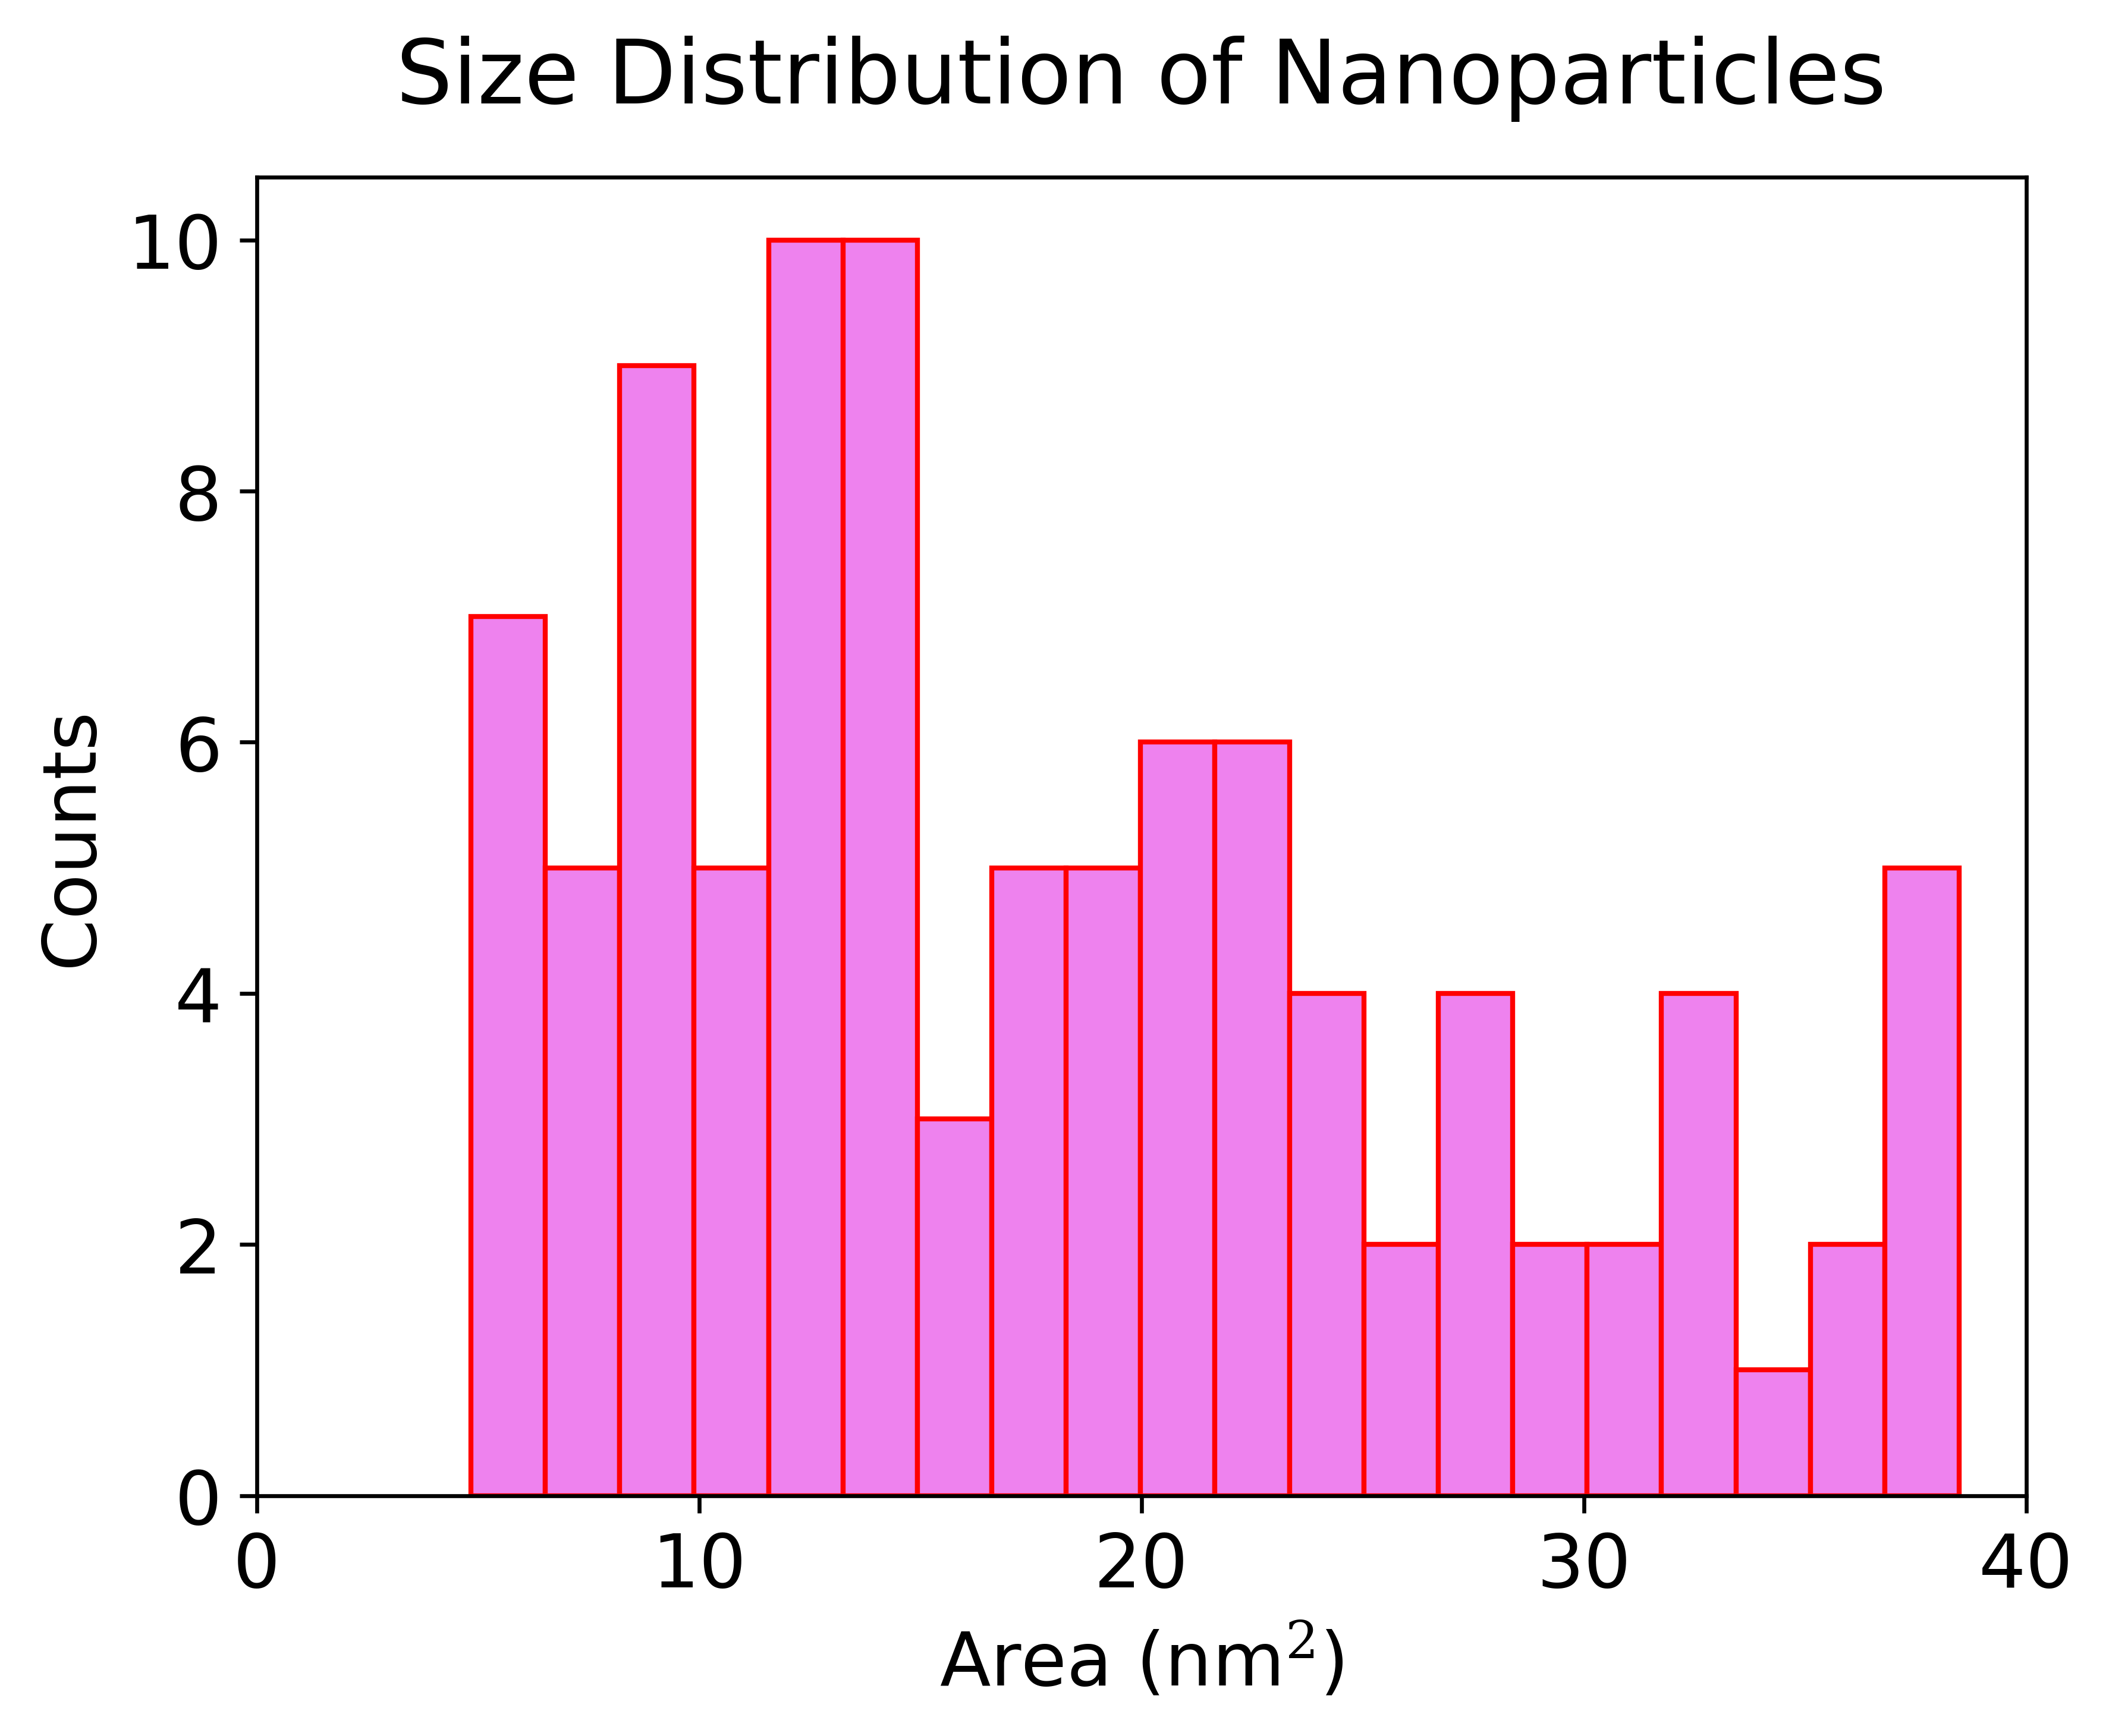

In [15]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc, font_manager

# Check if CSV file exists
if not os.path.exists('0_Measurements.csv'):
    print("Error: '0_Measurements.csv' not found!")
    print("Please run the particle measurement code first to generate the CSV file.")
else:
    rcParams['figure.dpi'] = 600
    rc('font', family='Times New Roman', size=15)
    rcParams['axes.titlepad'] = 15
    rcParams['mathtext.fontset'] = 'dejavuserif'
    ticks_font = font_manager.FontProperties(family='Times New Roman', style='normal',
    size=15, weight='normal', stretch='normal')
    axis_font = {'fontname':'Times New Roman','fontsize':15}

    data = pd.read_csv('0_Measurements.csv')

    # Check if data is empty
    if data.empty:
        print("Error: CSV file is empty!")
    else:
        index = data[(data['Area'] >= 40) | (data['Area'] <= 4)].index
        data.drop(index, inplace=True)
        de = data['Area'].describe()
        print(de)

        x = data.Area
        num_bins = 20

        fig, ax = plt.subplots()

        # the histogram of the data
        n, bins, patches = ax.hist(x, num_bins, color='violet', stacked=True, edgecolor='red')

        ax.set_xlim(0, 40)
        ax.set_xlabel('Area (nm$^2$)')
        ax.set_ylabel('Counts')
        ax.set_title(r'Size Distribution of Nanoparticles')

        plt.savefig('0_SizeDistribution.jpg')
        plt.show()

count    97.000000
mean      4.672290
std       1.218799
min       2.482918
25%       3.833918
50%       4.581339
75%       5.576174
max       7.000171
Name: Area, dtype: float64


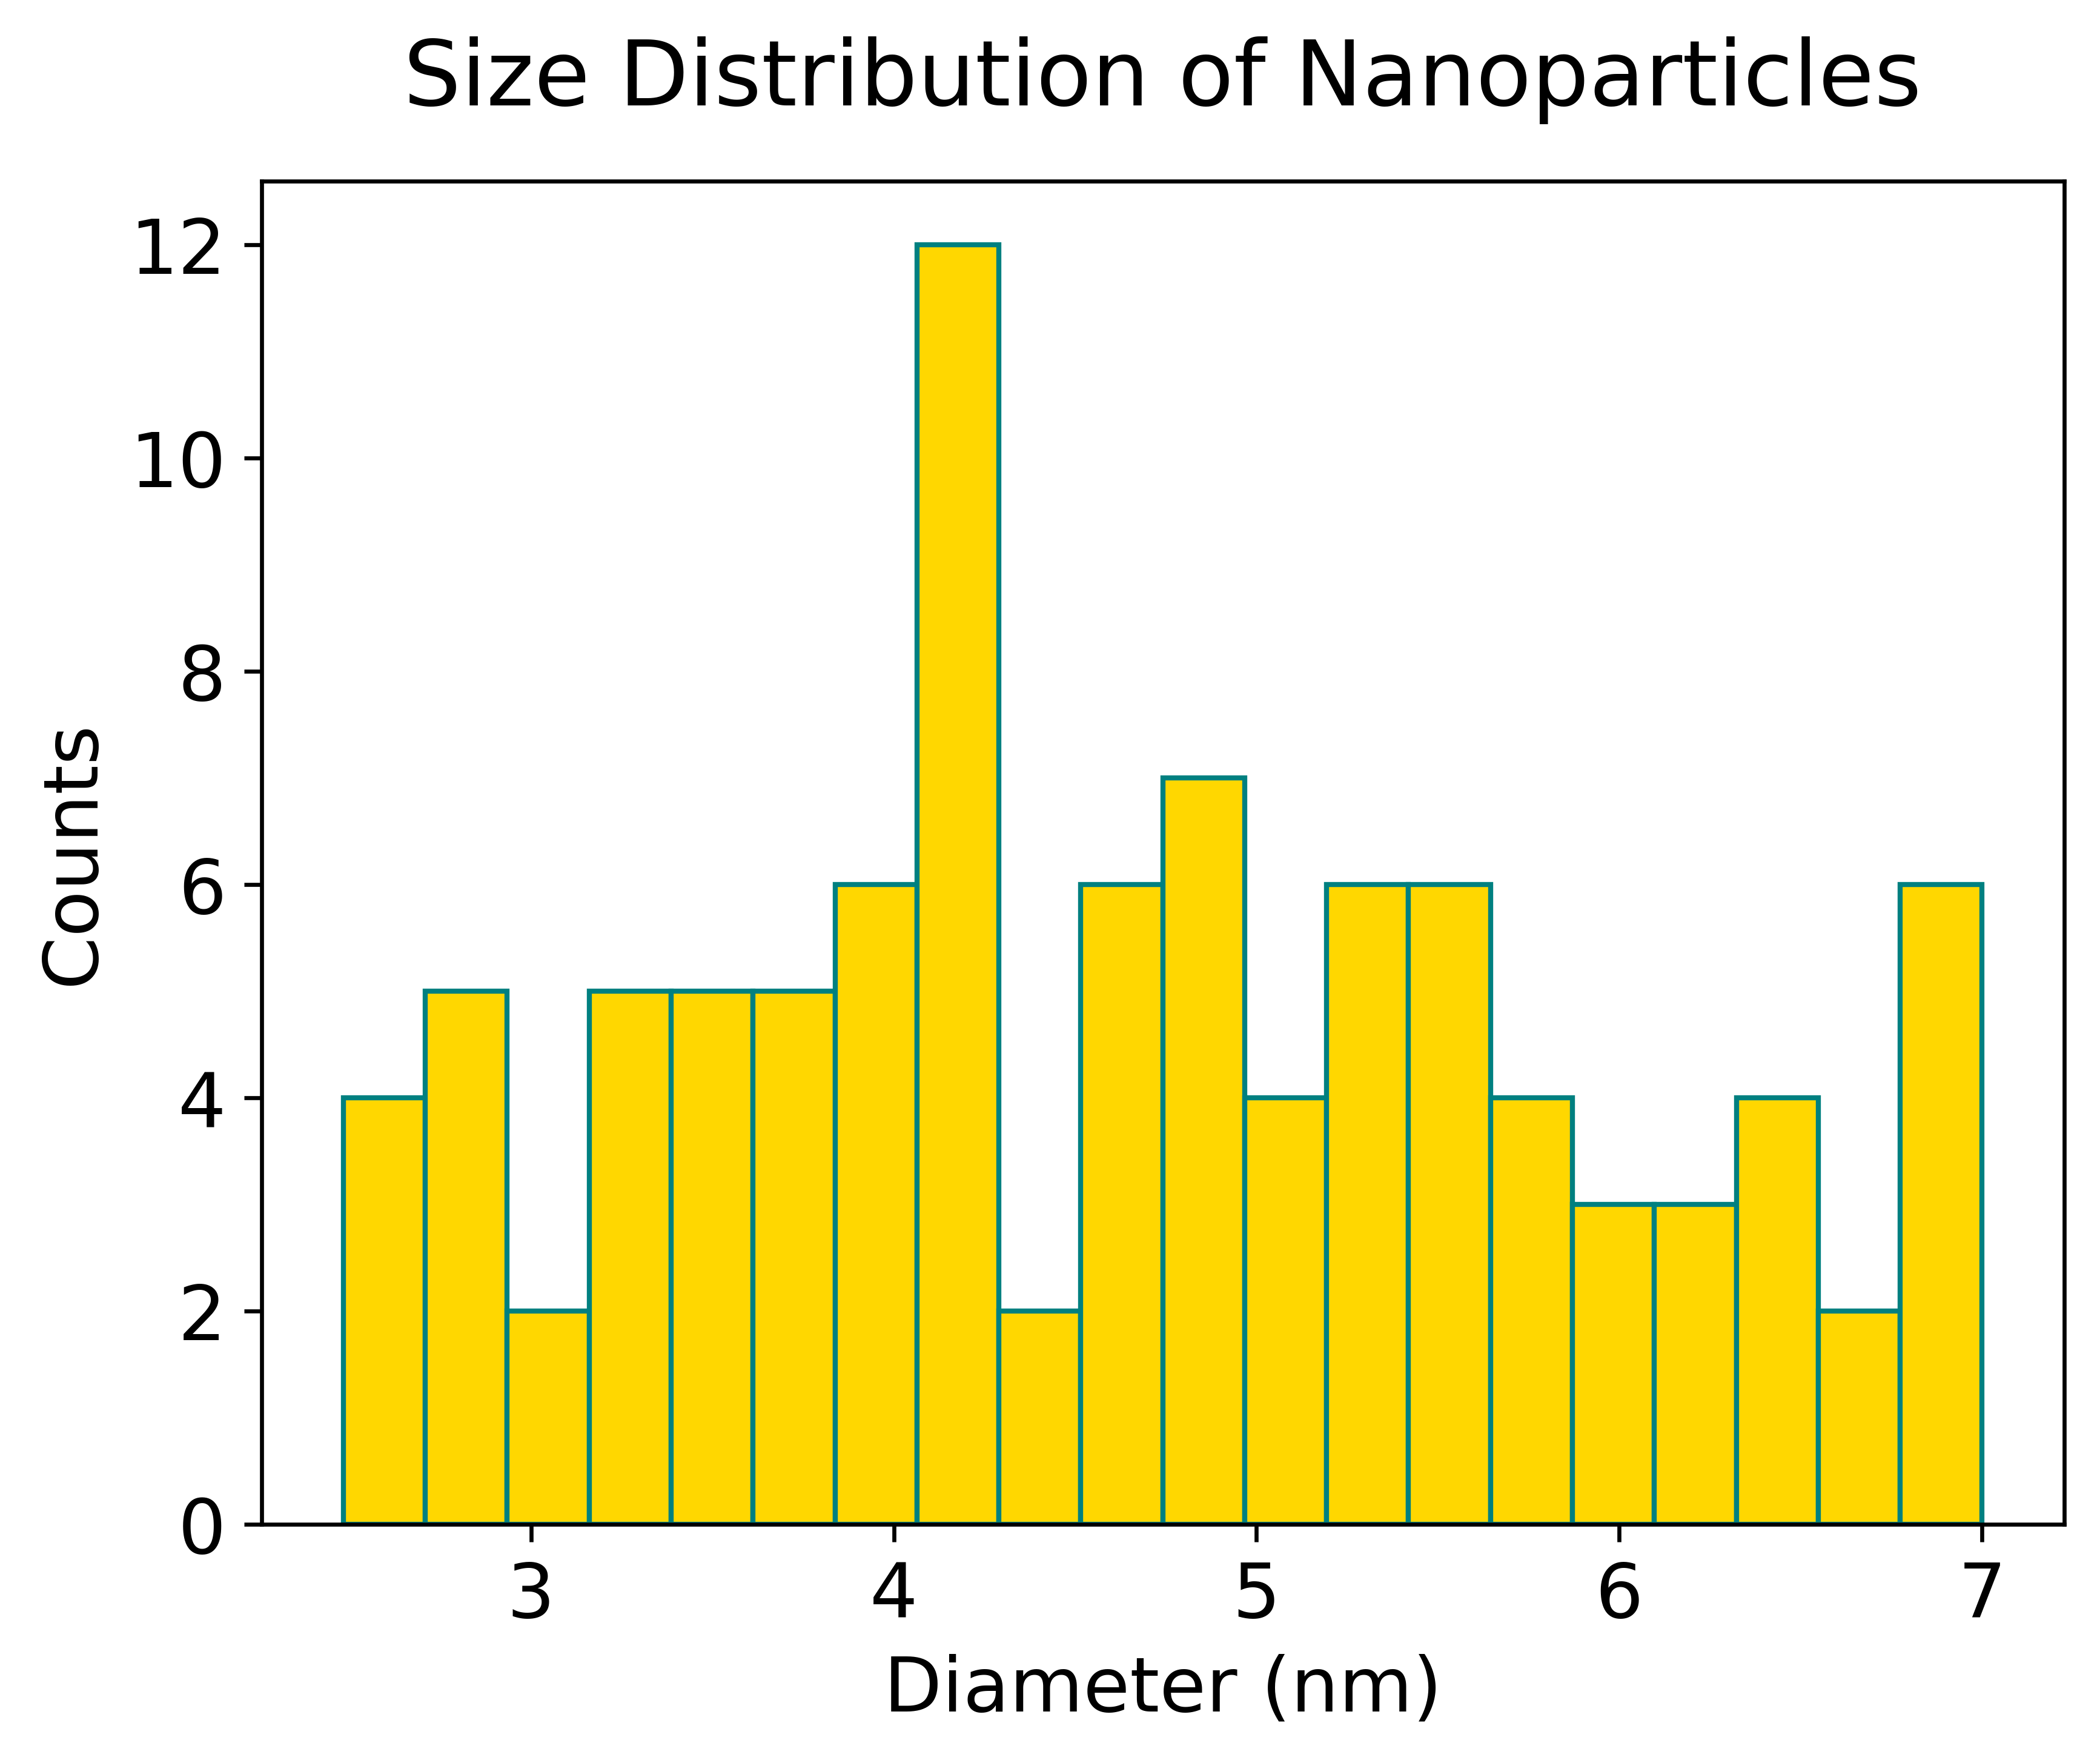

In [16]:
from math import sqrt, pi

data = pd.read_csv('0_Measurements.csv')

index = data[(data['Area'] >= 40)|(data['Area'] <= 4)].index
data.drop(index, inplace=True)
data['Area'].describe()

x = (data.Area / pi) * 4
x = x**(0.5)
de = x.describe()

num_bins = 20

fig, ax = plt.subplots()

# the histogram of the data
n, bins, patches = ax.hist(x, num_bins, color='gold', stacked=True, edgecolor='teal')


ax.set_xlabel('Diameter (nm)')
ax.set_ylabel('Counts')
ax.set_title(r'Size Distribution of Nanoparticles')

#ax.set_xlim(2, 7)

plt.savefig('0_DiameterDistribution.jpg')
print(de)

count    97.000000
mean      0.000296
std       0.000124
min       0.000099
25%       0.000209
50%       0.000266
75%       0.000387
max       0.000627
Name: eccentricity, dtype: float64


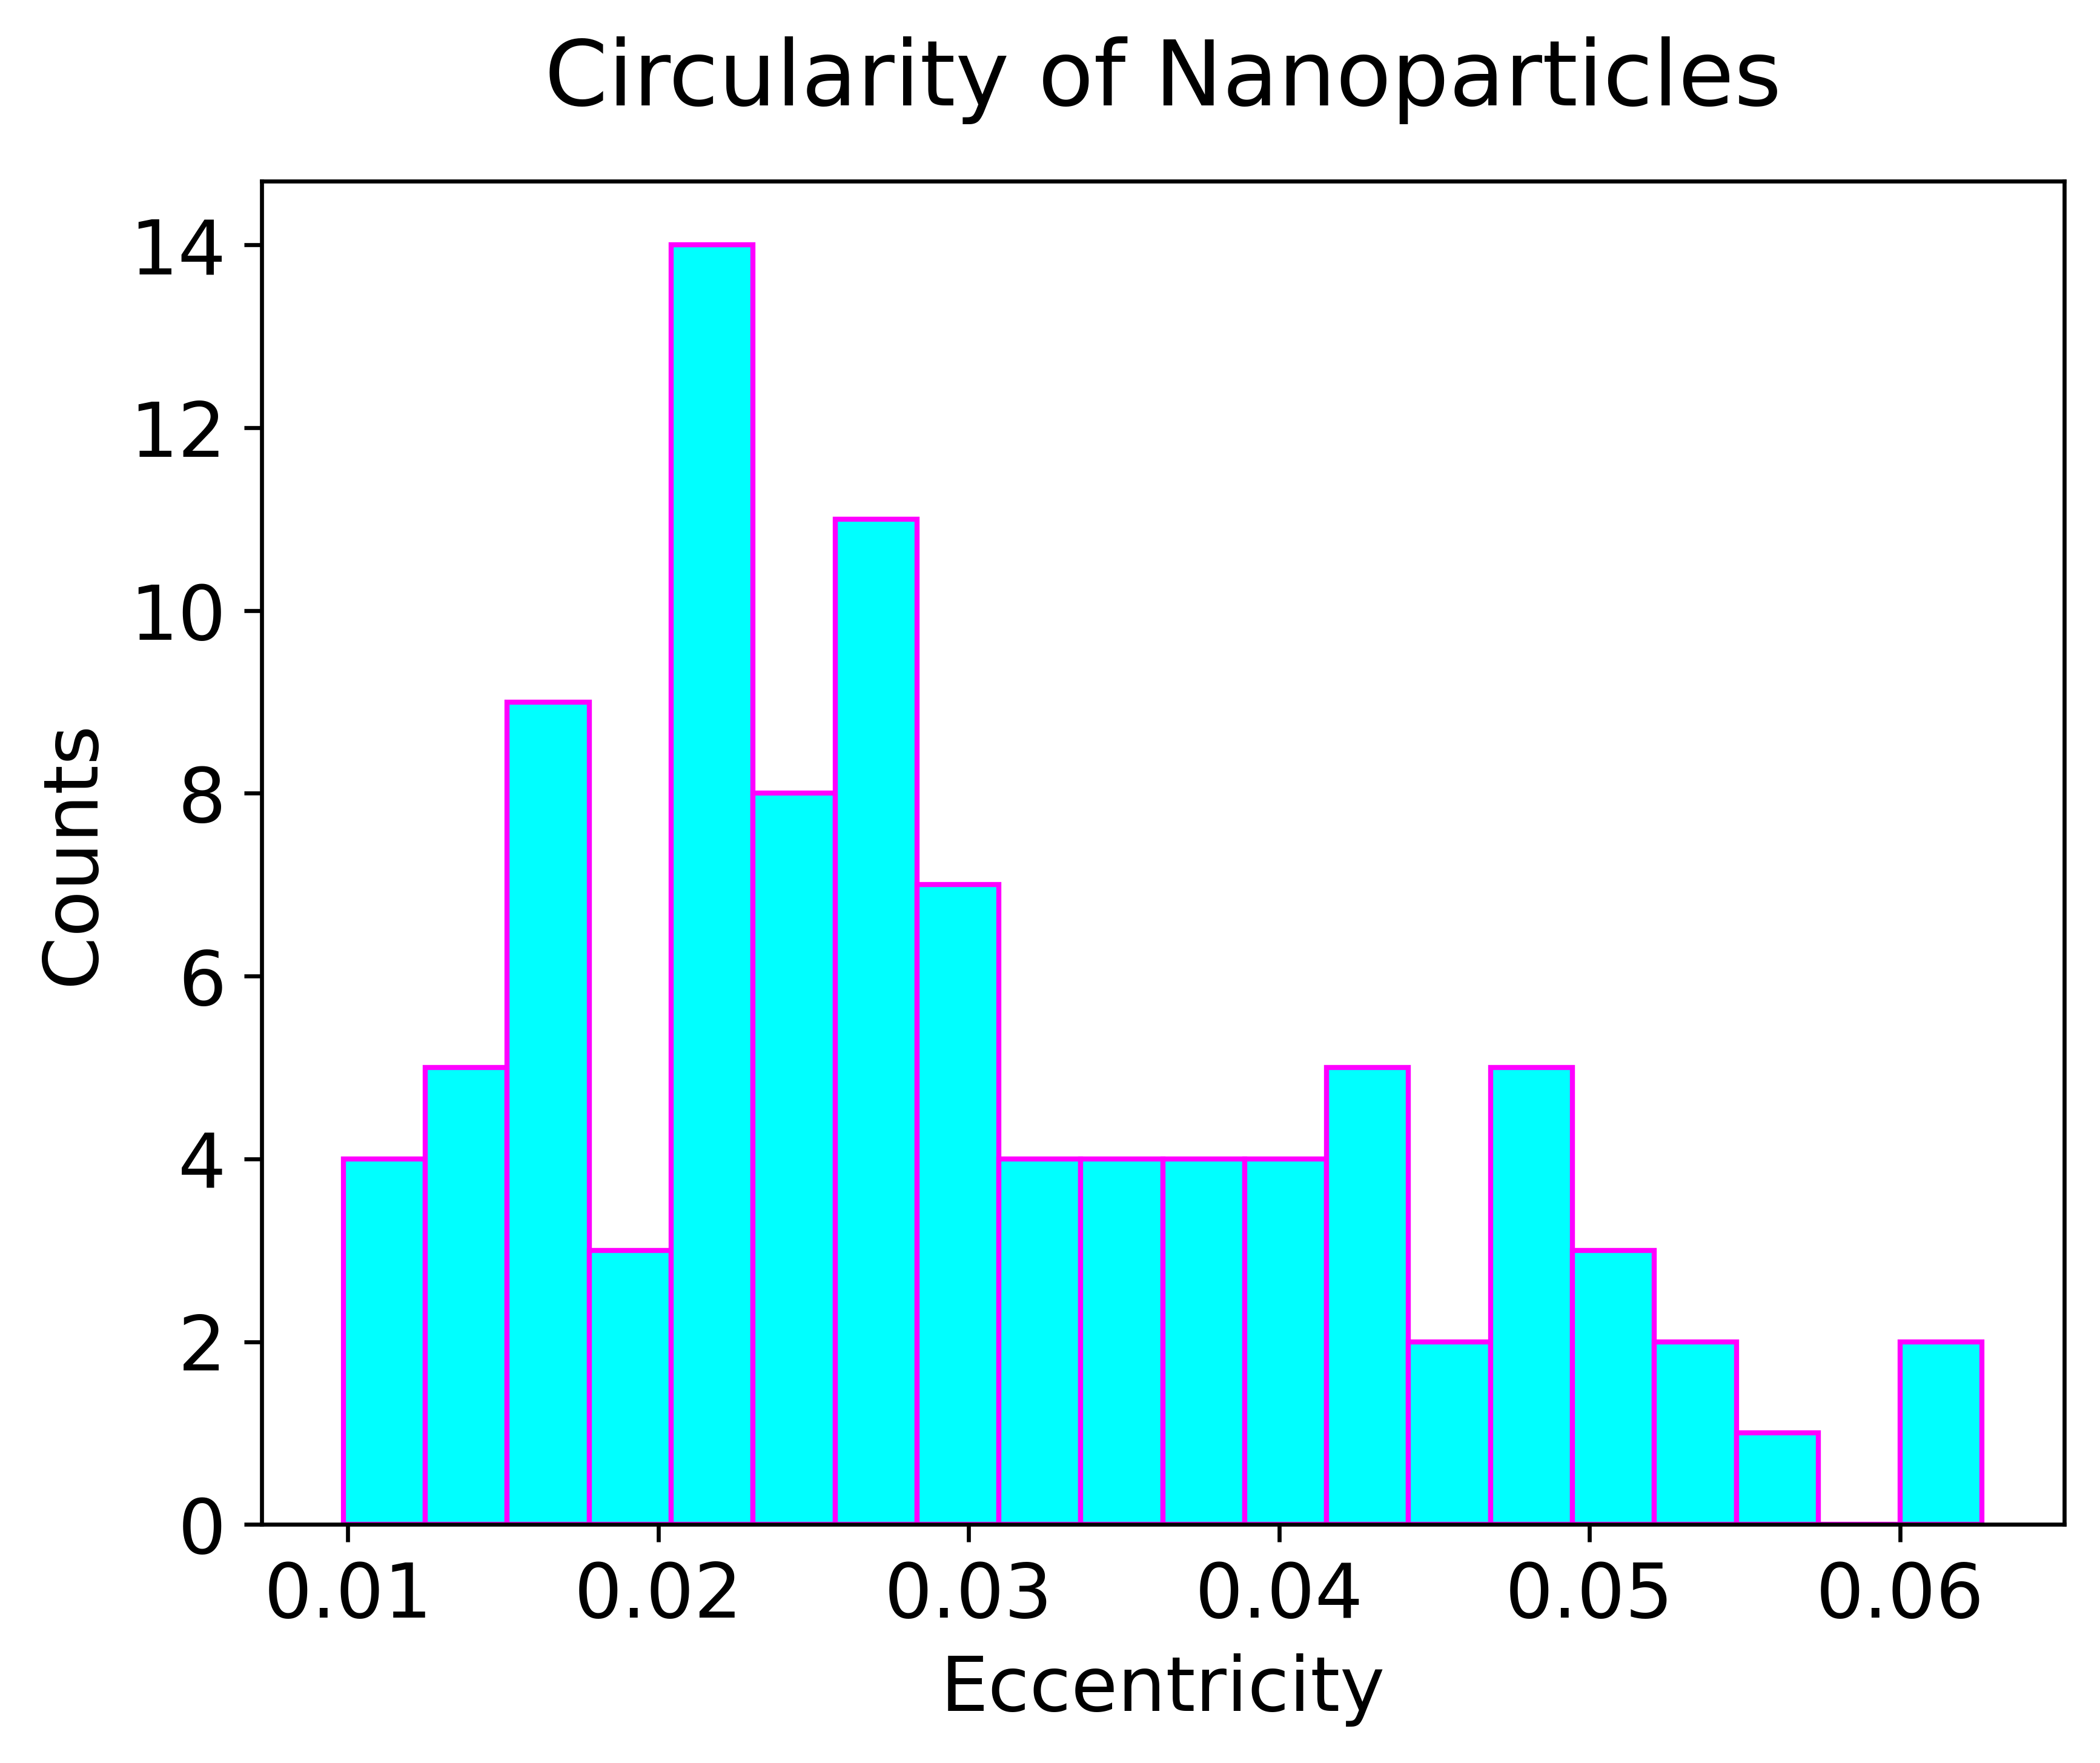

In [17]:
x = data.eccentricity *100

de = data['eccentricity'].describe()

num_bins = 20
fig, ax = plt.subplots()

# the histogram of the data
n, bins, patches = ax.hist(x, num_bins, color='cyan', stacked=True, edgecolor='magenta')

ax.set_xlabel('Eccentricity')
ax.set_ylabel('Counts')
ax.set_title(r'Circularity of Nanoparticles')

plt.savefig('0_EccentricityDistribution.jpg')
print(de)